In [2]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

df_tv = pd.read_csv("train_ind_prc.csv")
df_test = pd.read_csv("test_ind_prc.csv")
df_tv = df_tv.drop(['num__installment'], axis=1)
df_test = df_test.drop(['num__installment'], axis=1)


df_tv_exiti = df_tv.drop(['rf_rate','REAL_IRR'], axis=1)
df_test_exiti = df_test.drop(['rf_rate','REAL_IRR'], axis=1)

In [3]:
def cal_IRR(row):
    if row['pred_y'] == 1:
        return row['rf_rate']
    elif row['pred_y'] == 0:
        return row['REAL_IRR']
    else:
        return None

def cal_SR(df):
    excess_returns = df['IRR'] - df['rf_rate']
    if excess_returns.std() == 0:
        return 0
    return excess_returns.mean() / excess_returns.std()

In [6]:
# 최적 하이퍼파라미터를 찾기 위해 샘플 스플릿 with seed 0

X_tv = df_tv.drop('y', axis=1)
X_test = df_test.drop('y', axis=1)
y_tv = df_tv['y']
y_test = df_test['y']
X_train_R, X_val_R, y_train, y_val = train_test_split(X_tv, y_tv, stratify=y_tv, test_size=0.1, random_state=0)
X_train = X_train_R.drop(["rf_rate", "REAL_IRR"], axis=1)
X_val = X_val_R.drop(["rf_rate", "REAL_IRR"], axis=1)

import optuna

def objective(trial):
    # Optimize both var_smoothing AND threshold as separate hyperparameters
    var_smoothing = trial.suggest_loguniform("var_smoothing", 1e-11, 1e-7)
    threshold = trial.suggest_uniform("threshold", 0.01, 0.99)  # Add threshold as hyperparameter

    # Train the model
    model = GaussianNB(var_smoothing=var_smoothing)
    cal_model = CalibratedClassifierCV(model, method='sigmoid')
    cal_model.fit(X_train, y_train)
    
    # Get probabilities and apply the suggested threshold
    pred_y_proba = cal_model.predict_proba(X_val)[:, 1]
    pred_y = (pred_y_proba > threshold).astype(int)
    
    # Calculate Sharpe ratio for this specific combination
    X_val_R_copy = X_val_R.copy()  # Don't modify original
    X_val_R_copy['pred_y'] = pred_y
    X_val_R_copy['IRR'] = X_val_R_copy.apply(cal_IRR, axis=1)
    sr = cal_SR(X_val_R_copy)
    
    return sr

def optuna_nb(n_trials):
    best_results = []
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial), n_trials=n_trials)
    best_sr = study.best_value
    best_params = study.best_params
    best_results.append({
            'Sharpe': best_sr, 
            'params': best_params, 
        })
    return best_results

print("Running Optuna optimization for both var_smoothing and threshold...")
best_results = optuna_nb(n_trials=50)  # Increased trials since we have more parameters
print("Best results:", best_results[0])

[I 2025-08-21 10:44:47,645] A new study created in memory with name: no-name-e524f0bf-abff-4aa2-a8fa-4791228b9873


Running Optuna optimization for both var_smoothing and threshold...


[I 2025-08-21 10:44:50,491] Trial 0 finished with value: 0.08371030460591898 and parameters: {'var_smoothing': 2.147294760335623e-08, 'threshold': 0.5269625867944147}. Best is trial 0 with value: 0.08371030460591898.
[I 2025-08-21 10:44:53,151] Trial 1 finished with value: 0.08371030460591898 and parameters: {'var_smoothing': 3.5642835050097844e-10, 'threshold': 0.6143411869877237}. Best is trial 0 with value: 0.08371030460591898.
[I 2025-08-21 10:44:53,151] Trial 1 finished with value: 0.08371030460591898 and parameters: {'var_smoothing': 3.5642835050097844e-10, 'threshold': 0.6143411869877237}. Best is trial 0 with value: 0.08371030460591898.
[I 2025-08-21 10:44:55,820] Trial 2 finished with value: 0.12778134338169655 and parameters: {'var_smoothing': 4.897252568476541e-11, 'threshold': 0.21578046160288947}. Best is trial 2 with value: 0.12778134338169655.
[I 2025-08-21 10:44:55,820] Trial 2 finished with value: 0.12778134338169655 and parameters: {'var_smoothing': 4.897252568476541e

Best results: {'Sharpe': 0.1471781647551725, 'params': {'var_smoothing': 3.96210703320101e-08, 'threshold': 0.14945023590337939}}


Running bootstrap threshold optimization with fixed hyperparameters...

=== Bootstrap 1/100 ===
Bootstrap 1: Best Sharpe=0.1420, Threshold=0.165

=== Bootstrap 2/100 ===
Bootstrap 2: Best Sharpe=0.1418, Threshold=0.165

=== Bootstrap 3/100 ===
Bootstrap 3: Best Sharpe=0.1439, Threshold=0.165

=== Bootstrap 4/100 ===
Bootstrap 4: Best Sharpe=0.1422, Threshold=0.165

=== Bootstrap 5/100 ===
Bootstrap 5: Best Sharpe=0.1422, Threshold=0.165

=== Bootstrap 6/100 ===
Bootstrap 6: Best Sharpe=0.1411, Threshold=0.165

=== Bootstrap 7/100 ===
Bootstrap 7: Best Sharpe=0.1419, Threshold=0.165

=== Bootstrap 8/100 ===
Bootstrap 8: Best Sharpe=0.1428, Threshold=0.165

=== Bootstrap 9/100 ===
Bootstrap 9: Best Sharpe=0.1423, Threshold=0.165

=== Bootstrap 10/100 ===
Bootstrap 10: Best Sharpe=0.1426, Threshold=0.165

=== Bootstrap 11/100 ===
Bootstrap 11: Best Sharpe=0.1431, Threshold=0.165

=== Bootstrap 12/100 ===
Bootstrap 12: Best Sharpe=0.1433, Threshold=0.165

=== Bootstrap 13/100 ===
Bootstrap

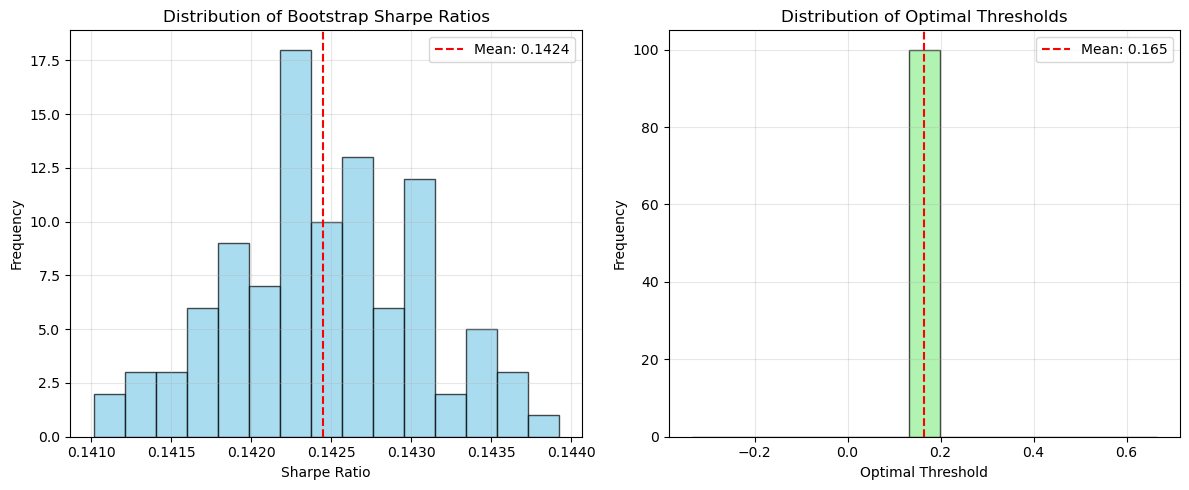

In [5]:
from sklearn.utils import resample

def bootstrap_threshold_optimization(df_tv, n_bootstrap, n_thresholds):
    best_results = []

    for i in range(n_bootstrap):
        print(f"\n=== Bootstrap {i+1}/{n_bootstrap} ===")
        
        # Bootstrap sampling
        df_boot = resample(df_tv, replace=True, n_samples=len(df_tv), random_state=i)
        X_tv = df_boot.drop('y', axis=1)
        y_tv = df_boot['y']
        X_test_R = df_test.drop('y', axis=1)

        

        X_train = X_tv.drop(["rf_rate", "REAL_IRR"], axis=1) 
        X_test = X_test_R.drop(["rf_rate", "REAL_IRR"], axis=1)

        model = GaussianNB(var_smoothing=3.96210703320101e-08)
        cal_model = CalibratedClassifierCV(model, method='sigmoid')
        cal_model.fit(X_train, y_tv)
        pred_y_proba = cal_model.predict_proba(X_test)[:, 1]

        thresholds = np.linspace(0.01, 0.99, n_thresholds)
        best_sr = -np.inf
        best_th = 0.5
        
        for th in thresholds:
            pred_y = (pred_y_proba > th).astype(int)
            X_test_R_copy = X_test_R.copy()
            X_test_R_copy['pred_y'] = pred_y
            X_test_R_copy['IRR'] = X_test_R_copy.apply(cal_IRR, axis=1)
            sr = cal_SR(X_test_R_copy)
            if sr > best_sr:
                best_sr = sr
                best_th = th
        best_results.append({
            'Bootstrap': i+1,
            'Sharpe': best_sr, 
            'threshold': best_th
        })
        
        print(f"Bootstrap {i+1}: Best Sharpe={best_sr:.4f}, Threshold={best_th:.3f}")

    return best_results

print("Running bootstrap threshold optimization with fixed hyperparameters...")
best_results = bootstrap_threshold_optimization(df_tv, n_bootstrap=100, n_thresholds=20)

# Display results
results_df = pd.DataFrame(best_results)
print("\n=== Final Results ===")
print(results_df[['Bootstrap', 'Sharpe', 'threshold']])
print(f"\nMean Sharpe: {results_df['Sharpe'].mean():.4f}")
print(f"Mean Threshold: {results_df['threshold'].mean():.4f}")
print(f"Std Sharpe: {results_df['Sharpe'].std():.4f}")
print(f"Best Sharpe: {results_df['Sharpe'].max():.4f}")

# Plot results
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of Sharpe ratios
ax1.hist(results_df['Sharpe'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(results_df['Sharpe'].mean(), color='red', linestyle='--', 
           label=f'Mean: {results_df["Sharpe"].mean():.4f}')
ax1.set_xlabel('Sharpe Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Bootstrap Sharpe Ratios')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of thresholds
ax2.hist(results_df['threshold'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(results_df['threshold'].mean(), color='red', linestyle='--',
           label=f'Mean: {results_df["threshold"].mean():.3f}')
ax2.set_xlabel('Optimal Threshold')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Optimal Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 최고 Sharpe의 부트스트랩 인덱스 (이미 계산되어 있다고 가정)
best_i = int(results_df.loc[results_df['Sharpe'].idxmax(), 'Bootstrap'])
print(f"Sharpe 최고 부트스트랩 인덱스: {best_i}")

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
import json, os
from datetime import datetime

# --- (선택) LGBM 스타일 키를 XGB로 정리하는 유틸 ---
def sanitize_xgb_params(optimal_params: dict) -> dict:
    p = dict(optimal_params) if optimal_params else {}

    # 이름 매핑(LGBM -> XGB)
    if 'learning_rate' in p and 'eta' not in p:
        p['eta'] = p.pop('learning_rate')
    if 'feature_fraction' in p and 'colsample_bytree' not in p:
        p['colsample_bytree'] = p.pop('feature_fraction')
    if 'bagging_fraction' in p and 'subsample' not in p:
        p['subsample'] = p.pop('bagging_fraction')

    # 필수/권장 기본값
    p.setdefault('objective', 'binary:logistic')
    p.setdefault('eval_metric', 'auc')
    p.setdefault('seed', 0)

    # XGB가 모를 가능성 있는 키 안전 제거(있으면 지우기)
    invalid_keys = {
        'bagging_freq','min_data_in_leaf','num_leaves','lambda_l1','lambda_l2',
        'max_bin','min_split_gain','metric'
    }
    for k in list(p.keys()):
        if k in invalid_keys:
            p.pop(k, None)

    return p

def retrain_one_bootstrap_and_save(
    df_tv, df_test, i, optimal_params,
    n_thresholds=20,
    model_save_path="xgb_final_model.json",
    meta_save_path="xgb_final_model.meta.json"
):
    """
    i: 부트스트랩 번호(1-based). bootstrap 시드는 random_state=i-1로 맞춰 재현.
    """
    # --- 데이터 부트스트랩 & 분할 (원래 루틴 재현) ---
    # 주의: Bootstrap 컬럼이 1부터 시작하므로, random_state=i-1이 원 루프의 i(0-based)와 일치
    df_boot = resample(df_tv, replace=True, n_samples=len(df_tv), random_state=i-1)

    X_tv = df_boot.drop('y', axis=1)
    y_tv = df_boot['y']
    X_test_R = df_test.drop('y', axis=1)

    X_train_R, X_val_R, y_train, y_val = train_test_split(
        X_tv, y_tv, stratify=y_tv, test_size=0.1, random_state=0
    )

    drop_cols = ["rf_rate", "REAL_IRR"]
    X_train = X_train_R.drop(drop_cols, axis=1)
    X_val   = X_val_R.drop(drop_cols, axis=1)
    X_test  = X_test_R.drop(drop_cols, axis=1)

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val, label=y_val)
    dtest  = xgb.DMatrix(X_test)

    # --- 파라미터 정리 & 재학습 ---
    params = sanitize_xgb_params(optimal_params)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=200,
        evals=[(dtrain, 'train'), (dval, 'valid')],
        verbose_eval=False
    )

    pred_y_proba = model.predict(dtest)

    # --- 최적 threshold 탐색(동일 grid) ---
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    best_sr, best_th = -np.inf, 0.5

    for th in thresholds:
        pred_y = (pred_y_proba > th).astype(int)
        X_test_copy = X_test_R.copy()
        X_test_copy['pred_y'] = pred_y
        X_test_copy['IRR'] = X_test_copy.apply(cal_IRR, axis=1)
        sr = cal_SR(X_test_copy)
        if sr > best_sr:
            best_sr, best_th = sr, th

    # --- 모델 저장 ---
    model.save_model(model_save_path)

    # --- 메타 저장(재현과 배포를 위해 threshold/Sharpe/feature 목록 포함) ---
    meta = {
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "bootstrap_index_1based": int(i),
        "best_threshold": float(best_th),
        "best_sharpe": float(best_sr),
        "features": list(X_train.columns),
        "xgb_params": params
    }
    with open(meta_save_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"✅ Saved final model to: {model_save_path}")
    print(f"✅ Saved meta to:      {meta_save_path}")
    print(f"[Reproduced] Bootstrap {i}: Sharpe={best_sr:.4f}, threshold={best_th:.3f}")

    # SHAP 계산용 피처 반환(X_test), threshold/Sharpe도 함께 반환
    return model, X_test, best_th, best_sr

# === 실행 예시 ===
# optimal_params는 당신이 검증에서 쓰던 XGBoost 하이퍼파라미터 dict를 그대로 입력
final_model, X_test_for_shap, best_th, best_sr = retrain_one_bootstrap_and_save(
    df_tv=df_tv,
    df_test=df_test,
    i=best_i,  # 1-based 인덱스 그대로 넣으면 함수 내에서 i-1로 시드 보정
    optimal_params=optimal_params,
    n_thresholds=20,
    model_save_path="xgb_final_model.json",
    meta_save_path="xgb_final_model.meta.json"
)


Sharpe 최고 부트스트랩 인덱스: 3


NameError: name 'optimal_params' is not defined